Number of samples: 569
Number of features: 30

Without Regularization:
Training Accuracy = 1.0
Testing Accuracy = 0.9385964912280702

Ridge:
Ridge Training Accuracy = 0.9868131868131869
Ridge Testing Accuracy = 0.9736842105263158

Lasso:
Lasso Training Accuracy = 0.989010989010989
Lasso Testing Accuracy = 0.9736842105263158

--- Model Comparison ---
Without Regularization Test Accuracy = 0.9385964912280702
Ridge Test Accuracy = 0.9736842105263158
Lasso Test Accuracy = 0.9736842105263158

--- Overfitting Comparison ---

Without Regularization:
Training Accuracy = 1.0
Testing Accuracy = 0.9385964912280702

Ridge:
Training Accuracy = 0.9868131868131869
Testing Accuracy = 0.9736842105263158

Lasso:
Training Accuracy = 0.989010989010989
Testing Accuracy = 0.9736842105263158


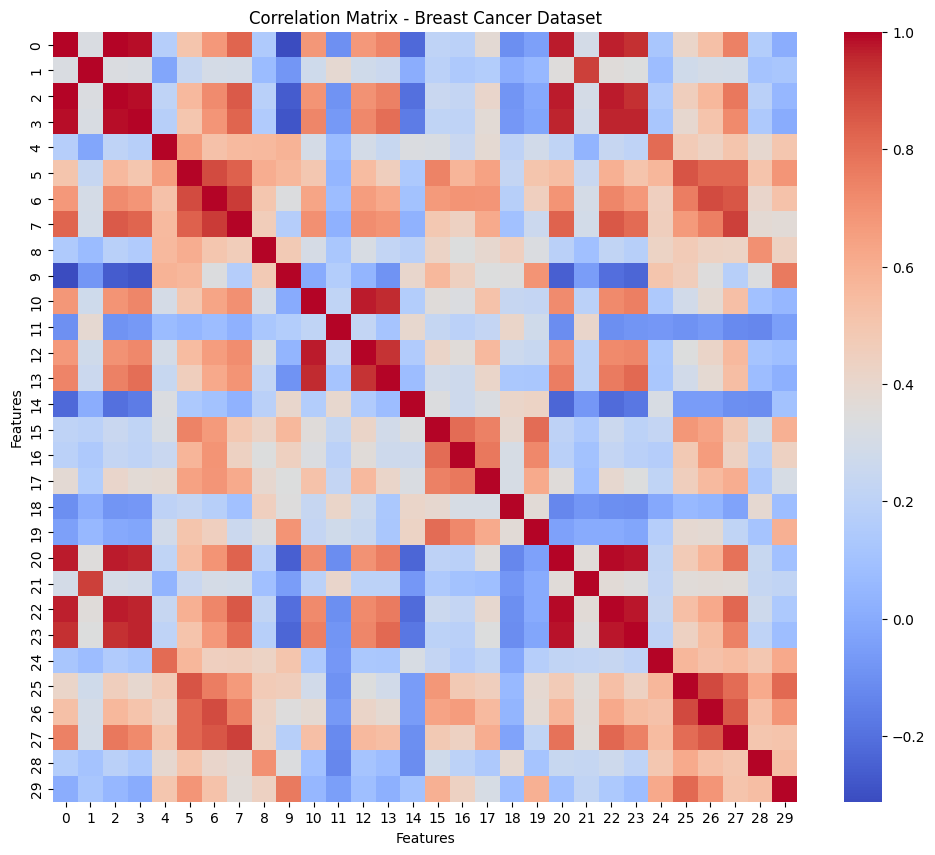

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
x = data.data
y = data.target

print("Number of samples:", x.shape[0])
print("Number of features:", x.shape[1])

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Logistic Regression - Without Regularization
model_None = LogisticRegression(
    penalty=None,
    max_iter=5000
)

model_None.fit(x_train, y_train)

train_pred = model_None.predict(x_train)
test_pred = model_None.predict(x_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("\nWithout Regularization:")
print("Training Accuracy =", train_accuracy)
print("Testing Accuracy =", test_accuracy)

# Logistic Regression - Ridge (L2)
model_Ridge = LogisticRegression(
    penalty='l2',
    C=1.0,
    max_iter=5000
)

model_Ridge.fit(x_train, y_train)

train_pred_Ridge = model_Ridge.predict(x_train)
test_pred_Ridge = model_Ridge.predict(x_test)

train_accuracy_Ridge = accuracy_score(
    y_train, train_pred_Ridge
)
test_accuracy_Ridge = accuracy_score(
    y_test, test_pred_Ridge
)

print("\nRidge:")
print("Ridge Training Accuracy =", train_accuracy_Ridge)
print("Ridge Testing Accuracy =", test_accuracy_Ridge)

# Logistic Regression - Lasso (L1)
model_Lasso = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',
    max_iter=5000
)

model_Lasso.fit(x_train, y_train)

train_pred_Lasso = model_Lasso.predict(x_train)
test_pred_Lasso = model_Lasso.predict(x_test)

train_accuracy_Lasso = accuracy_score(
    y_train, train_pred_Lasso
)
test_accuracy_Lasso = accuracy_score(
    y_test, test_pred_Lasso
)

print("\nLasso:")
print("Lasso Training Accuracy =", train_accuracy_Lasso)
print("Lasso Testing Accuracy =", test_accuracy_Lasso)

# Model Comparison
print("\n--- Model Comparison ---")

print(
    "Without Regularization Test Accuracy =",
    test_accuracy
)

print(
    "Ridge Test Accuracy =",
    test_accuracy_Ridge
)

print(
    "Lasso Test Accuracy =",
    test_accuracy_Lasso
)

# Overfitting Comparison
print("\n--- Overfitting Comparison ---")

print("\nWithout Regularization:")
print("Training Accuracy =", train_accuracy)
print("Testing Accuracy =", test_accuracy)

print("\nRidge:")
print("Training Accuracy =", train_accuracy_Ridge)
print("Testing Accuracy =", test_accuracy_Ridge)

print("\nLasso:")
print("Training Accuracy =", train_accuracy_Lasso)
print("Testing Accuracy =", test_accuracy_Lasso)

# Multicollinearity - Correlation Matrix
correlation = pd.DataFrame(x).corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm"
)

plt.title("Correlation Matrix - Breast Cancer Dataset")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()